# K-Means Exploration

This script uses the unified_dataset.csv and run a K-means clustering algorithm on it. It uses a subset of the data and scales it via standard scaling. Then it provdes an overview of the K-means algorithm that has the most optimal number of k clusters using the Calinski-Harabasz Score, elbow method, and the silhouette score. It also provides the top features that differentiate clusters. 

The test data is 40% of the original data.

Font: Liberation Sans


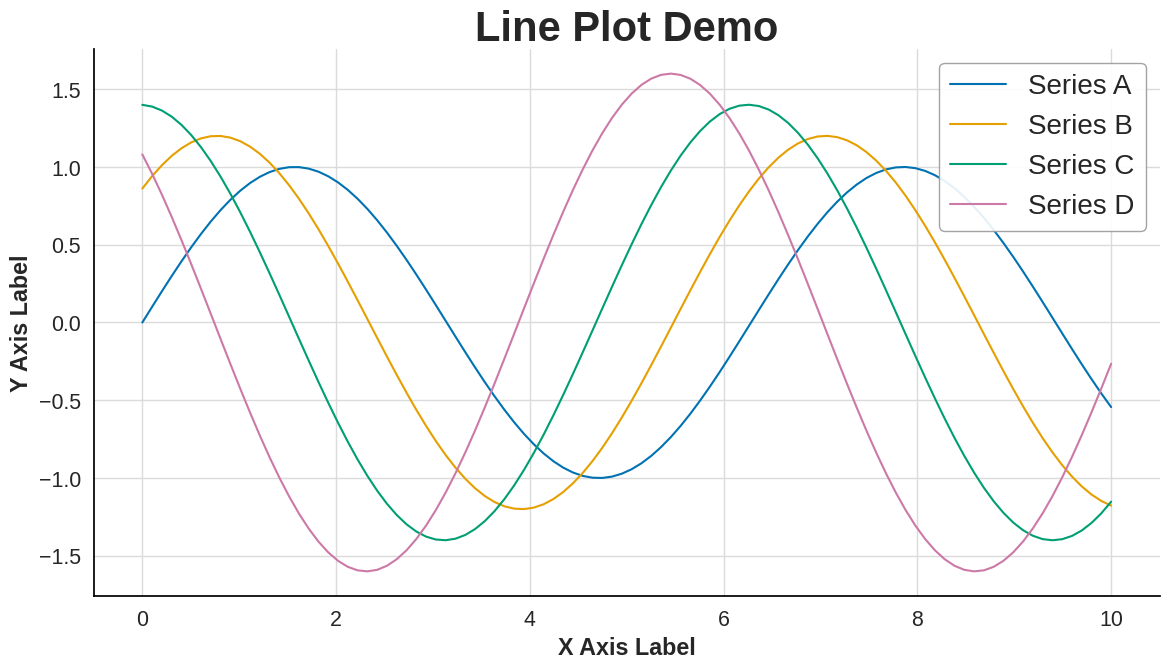

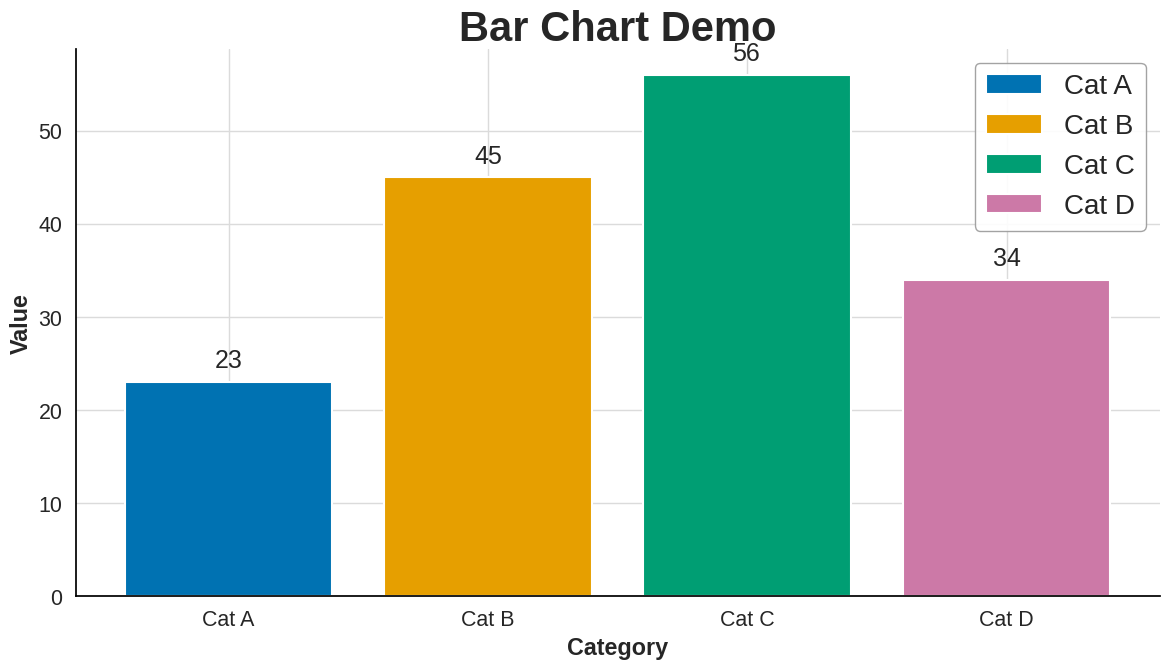

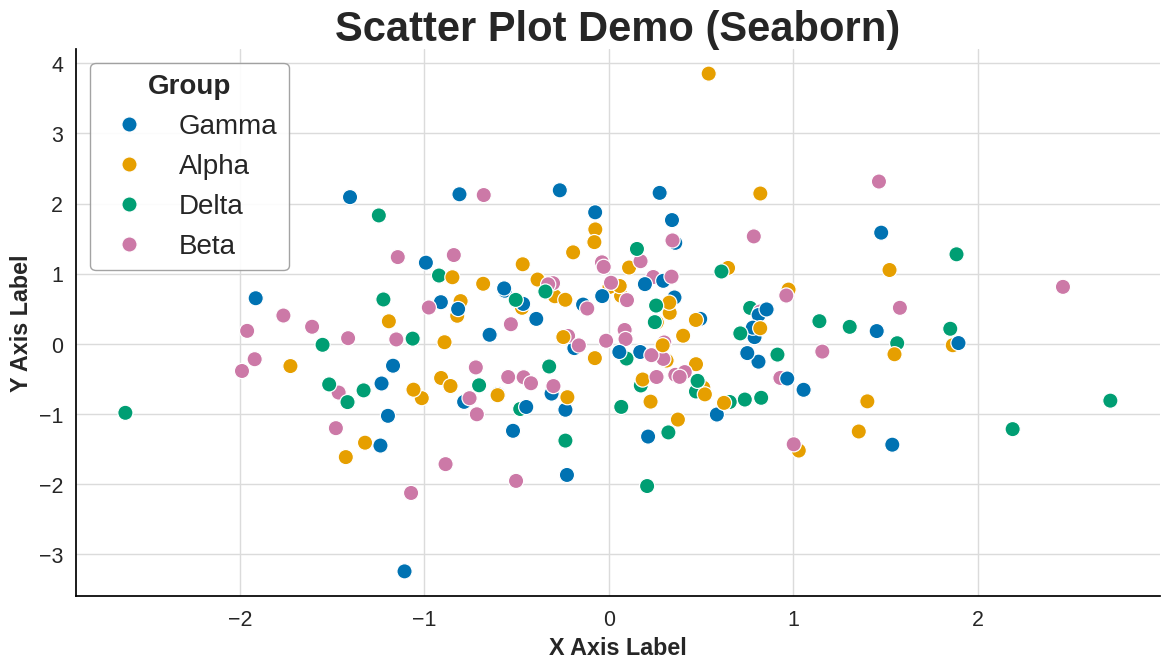

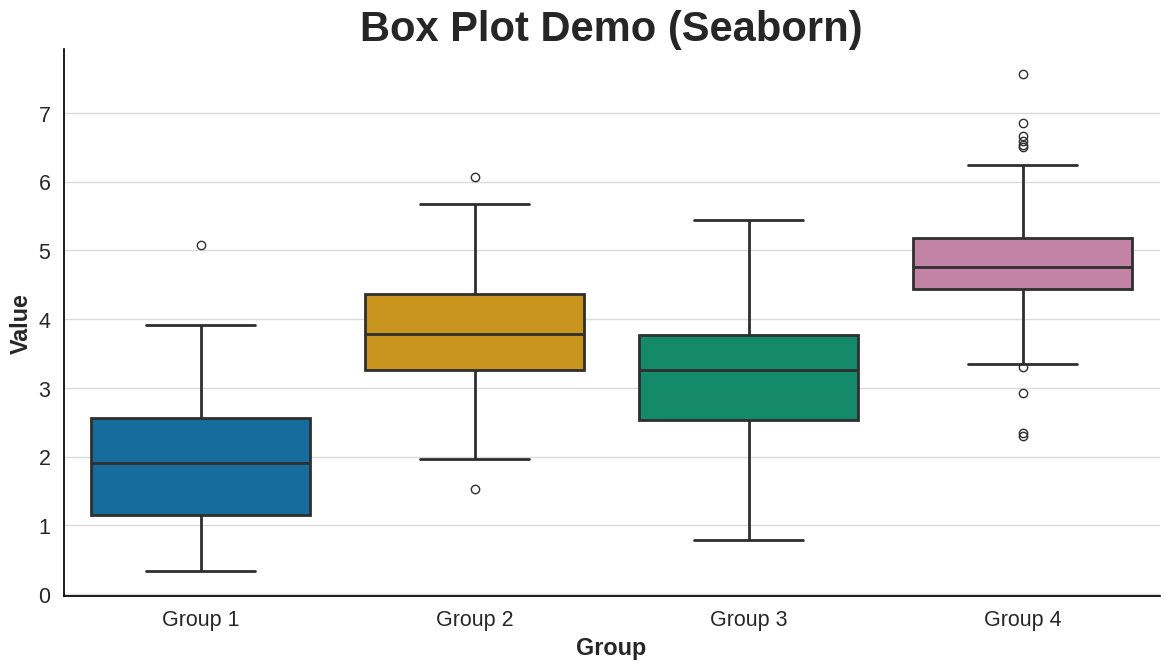

In [2]:
!pip install --upgrade scikit-learn

In [3]:
!pip install kneed

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [5]:
data = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/unified_dataset.csv")

In [6]:
# Remove NAs
%matplotlib inline

subset=data.iloc[:, 0:len(data.columns)].copy()

display(subset[subset.isna().any(axis=1)])

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_sbmtd_chrg_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplr_benes_sum,tot_suplrs_median,...,specialty_lvl1_Behavioral Health & Social Service Providers,specialty_lvl1_Dental Providers,specialty_lvl1_Eye and Vision Services Providers,specialty_lvl1_Nursing Service Providers,specialty_lvl1_Other Service Providers,specialty_lvl1_Pharmacy Service Providers,specialty_lvl1_Physician Assistants & Advanced Practice Nursing Providers,specialty_lvl1_Podiatric Medicine & Surgery Service Providers,specialty_lvl1_Student,active_medicaid_provider_flag


### Prep the Data

In [7]:
subset.shape

(140827, 96)

In [8]:
from sklearn.model_selection import train_test_split

# X = all columns except 'target'
X = subset.drop(columns=['target']).select_dtypes(include='number')
# y = target column
y = subset['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 69,
    stratify=y,   # keep class ratio
)

In [9]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [10]:
X_scaled.shape

(112661, 80)

In [11]:
X_small = X_scaled.copy()

### K Means Modeling

In [12]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Fit KMeans on scaled features
kmeans_model = KMeans(
    init='k-means++',
    n_clusters=4,
    n_init=10,          # <- changed from 'auto' to an int
    random_state=42
)
labels = kmeans_model.fit_predict(X_small)

print("Cluster Characteristics")

# If X_scaled is a NumPy array, make a DataFrame so we can label columns
if not isinstance(X_small, pd.DataFrame):
    X_scaled_df = pd.DataFrame(X_small, columns=X.columns)
else:
    X_scaled_df = X_small.copy()

# Add Cluster labels
clustered_df = X_scaled_df.copy()
clustered_df['Cluster'] = labels

# Numeric columns (all of them except Cluster)
numeric_cols = clustered_df.select_dtypes(include='number').columns.drop('Cluster')

# Per-cluster means for all numeric features
cluster_means = clustered_df.groupby('Cluster')[numeric_cols].mean()

# How much each feature varies between clusters
feature_separation = cluster_means.std(axis=0)

# Pick top N most cluster-separating features
top_n = 15
top_features = feature_separation.sort_values(ascending=False).head(top_n).index

# Summary stats for just those features
cluster_summary = (
    clustered_df
    .groupby('Cluster')[top_features]
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)

print("Top features that differentiate clusters:")
print(feature_separation.sort_values(ascending=False).head(top_n))

print("\nCluster summary for top features:")
print(cluster_summary)


Cluster Characteristics
Top features that differentiate clusters:
tot_suplr_benes_sum               1.597767
bene_age_lt_65_cnt                1.544651
bene_age_gt_84_cnt                1.537305
tot_suplr_nonrntl_hcpcs_cds       1.336805
bene_cc_ph_asthma_v2_pct          1.261915
tot_suplrs_max                    1.198571
bene_cc_ph_osteoporosis_v2_pct    1.161360
bene_cc_ph_hf_non_ihd_v2_pct      1.126874
bene_cc_bh_tobacco_v1_pct         1.125294
tot_suplr_rentl_hcpcs_cds         1.118844
bene_cc_bh_anxiety_v1_pct         1.093738
bene_cc_ph_cancer6_v2_pct         1.086929
bene_cc_ph_stroke_tia_v2_pct      1.086396
bene_race_black_cnt               1.072656
bene_cc_ph_copd_v2_pct            1.071822
dtype: float64

Cluster summary for top features:
        tot_suplr_benes_sum                       bene_age_lt_65_cnt         \
                       mean    std    min     max               mean    std   
Cluster                                                                       
0 

In [13]:
# ============================================================================
# Determine Optimal K - Elbow Method with Knee Detection
# ============================================================================
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import MiniBatchKMeans
print("Finding Optimal K")


# For large datasets, use MiniBatchKMeans for efficiency
use_minibatch = X_small.shape[0] > 10000

print(f"Dataset size: {X_small.shape[0]:,} samples")
print(f"Using: {'MiniBatchKMeans' if use_minibatch else 'KMeans'} for efficiency")

k_range = range(5, 25)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

print("\nTesting different values of K...")
for k in k_range:
    if use_minibatch:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, 
                                 batch_size=1024, n_init=10)
    else:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_small)
    labels = kmeans.labels_
    
    inertias.append(kmeans.inertia_)
    
    # For large datasets, sample for silhouette score (computationally expensive)
    if X_scaled.shape[0] > 10000:
        sample_size = 5000
        indices = np.random.choice(X_small.shape[0], sample_size, replace=False)
        sil_score = silhouette_score(X_small[indices], labels[indices])
    else:
        sil_score = silhouette_score(X_small, labels)
    
    silhouette_scores.append(sil_score)
    calinski_scores.append(calinski_harabasz_score(X_small, labels))
    davies_scores.append(davies_bouldin_score(X_small, labels))  # Store Davies-Bouldin score

    print(  # Print metrics for this k
        f"  K={k:2d}: Inertia={kmeans.inertia_:12,.0f}, "
        f"Silhouette={sil_score:.3f}, "
        f"Calinski={calinski_scores[-1]:10,.0f}, "
        f"Davies={davies_scores[-1]:.3f}")

Finding Optimal K
Dataset size: 112,661 samples
Using: MiniBatchKMeans for efficiency

Testing different values of K...
  K= 5: Inertia=   7,503,244, Silhouette=0.102, Calinski=     4,928, Davies=2.398
  K= 6: Inertia=   7,493,890, Silhouette=0.109, Calinski=     4,044, Davies=2.804
  K= 7: Inertia=   7,268,937, Silhouette=0.118, Calinski=     4,038, Davies=2.951
  K= 8: Inertia=   7,191,918, Silhouette=0.056, Calinski=     3,653, Davies=3.029
  K= 9: Inertia=   7,159,977, Silhouette=0.114, Calinski=     3,265, Davies=3.007
  K=10: Inertia=   7,092,846, Silhouette=0.104, Calinski=     3,052, Davies=3.204
  K=11: Inertia=   7,028,266, Silhouette=0.048, Calinski=     2,886, Davies=3.134
  K=12: Inertia=   7,019,556, Silhouette=0.010, Calinski=     2,692, Davies=3.194
  K=13: Inertia=   6,969,855, Silhouette=-0.004, Calinski=     2,539, Davies=3.161
  K=14: Inertia=   6,920,957, Silhouette=0.005, Calinski=     2,420, Davies=3.332
  K=15: Inertia=   6,840,773, Silhouette=0.007, Calinski=  

In [14]:
from kneed import KneeLocator

# k_range is something like range(7, 40)
k_list = list(k_range)

# inertias is  list of inertia values for each k
kl = KneeLocator(
    k_list,
    inertias,
    curve='convex',
    direction='decreasing'
)

elbow_k = kl.elbow   # this is the k at the elbow (or None if not found)
print("Detected elbow_k:", elbow_k)

Detected elbow_k: 11


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

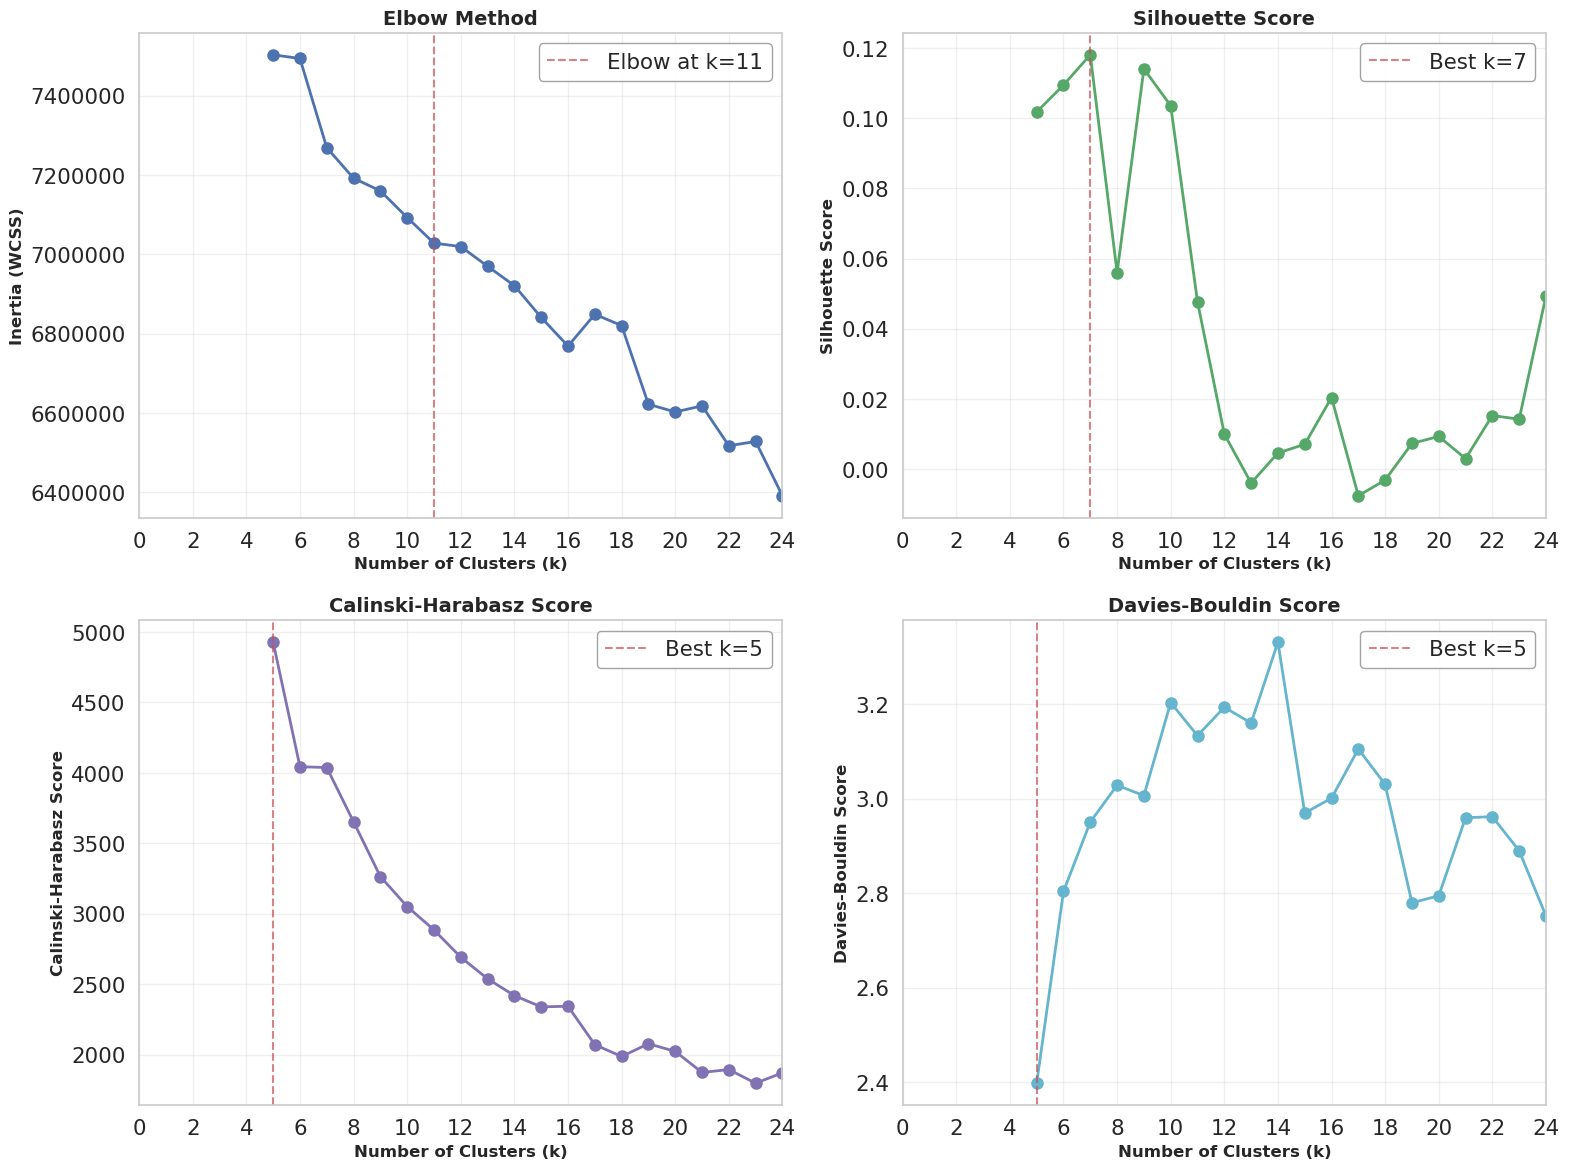

In [15]:
# ============================================================================
# Visualize All Metrics
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x_ticks = np.arange(0, int(np.max(k_range)) + 2, 2)  # Build x-axis ticks starting at 0 with step size 2
for ax in axes.flat:  # Iterate through all subplots
    ax.set_xlim(0, int(np.max(k_range)))  # Set x-axis lower bound to 0 and upper bound to max k
    ax.set_xticks(x_ticks)  # Apply consistent x-axis ticks at 0, 2, 4, ...

# Elbow Method with automatic detection
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
if elbow_k:
    axes[0, 0].axvline(x=elbow_k, color='r', linestyle='--', alpha=0.7, 
                       label=f'Elbow at k={elbow_k}')
axes[0, 0].legend()
axes[0, 0].ticklabel_format(style='plain', axis='y')

# Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
best_silhouette_k = k_range[np.argmax(silhouette_scores)]
axes[0, 1].axvline(x=best_silhouette_k, color='r', linestyle='--', alpha=0.7,
                   label=f'Best k={best_silhouette_k}')
axes[0, 1].legend()

# Calinski-Harabasz Score
axes[1, 0].plot(k_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Score', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
best_calinski_k = k_range[np.argmax(calinski_scores)]
axes[1, 0].axvline(x=best_calinski_k, color='r', linestyle='--', alpha=0.7,
                   label=f'Best k={best_calinski_k}')
axes[1, 0].legend()
axes[1, 0].ticklabel_format(style='plain', axis='y')

# Plot Davies-Bouldin scores across k
axes[1, 1].plot(k_range, davies_scores, 'co-', linewidth=2, markersize=8) 
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12) 
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[1, 1].set_title('Davies-Bouldin Score', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)  
best_davies_k = k_range[np.argmin(davies_scores)] 
axes[1, 1].axvline(x=best_davies_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_davies_k}')  
axes[1, 1].legend()  

plt.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

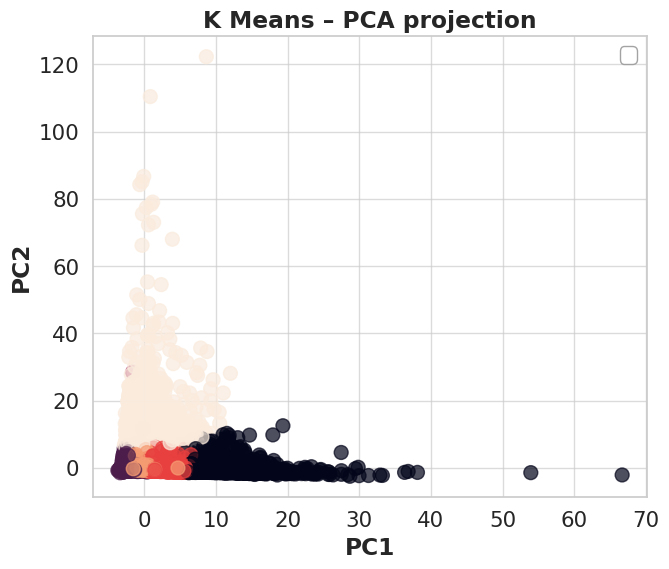

In [16]:
from sklearn.decomposition import PCA

k_values = np.array(list(k_range))  # Convert k_range to NumPy array
kmeans_best = KMeans(n_clusters=6, random_state=42, n_init=10)  # Initialize KMeans with best k
labels_best = kmeans_best.fit_predict(X_small)  # Fit KMeans and get cluster labels

# Project to 2D for visualization only
pca = PCA(n_components=2, random_state=42) 
X_2d = pca.fit_transform(X_small) 

plt.figure(figsize=(7, 6)) 
plt.scatter(X_2d[:, 0], X_2d[:, 1], 
            c=labels_best, 
            s=100, alpha=0.7
)  
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K Means – PCA projection")
plt.legend()
plt.tight_layout()
plt.show()